# YOLO Local Detection Visualization
This notebook loads the same YOLO detector used by the API and visualizes detections.
Run top-to-bottom. It uses settings from `app/core/config.py`.


In [1]:
import os
import sys
from pathlib import Path
from typing import List
from PIL import Image, ImageDraw, UnidentifiedImageError
import matplotlib.pyplot as plt

ROOT = Path('/workspace/PoC/dogface_fastapi_poc_qdrant')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)


ROOT: /workspace/PoC/dogface_fastapi_poc_qdrant


In [7]:
from app.core.config import settings
from app.ml.detector import YoloDetector

def parse_class_ids(s: str) -> List[int]:
    out = []
    for part in (s or '').split(','):
        part = part.strip()
        if not part:
            continue
        out.append(int(part))
    return out

keep_ids = parse_class_ids(settings.yolo_class_ids) if settings.yolo_class_ids else None
detector = YoloDetector(
    weights_path="/workspace/PoC/dogface_fastapi_poc_qdrant/weights/yolo/yolo26x-seg.pt",
    device=settings.device,
    imgsz=settings.yolo_imgsz,
    conf=settings.yolo_conf,
    iou=settings.yolo_iou,
    keep_class_ids=keep_ids,
    task=settings.yolo_task,
)

print('YOLO:', settings.yolo_weights_path)
print('device:', settings.device)
print('imgsz/conf/iou:', settings.yolo_imgsz, settings.yolo_conf, settings.yolo_iou)
print('keep_class_ids:', keep_ids)


YOLO: weights/yolo/yolo26x-seg.pt
device: cuda:0
imgsz/conf/iou: 640 0.25 0.45
keep_class_ids: [15, 16]


In [8]:
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def load_image(path: Path):
    try:
        return Image.open(path).convert('RGB')
    except UnidentifiedImageError:
        return None

def collect_images(dirs, exts=None, limit=12):
    exts = exts or {'.jpg', '.jpeg', '.png'}
    paths = []
    for d in dirs:
        if not d.exists():
            continue
        for p in d.rglob('*'):
            if p.suffix.lower() in exts:
                paths.append(p)
    return paths[:limit]

def draw_boxes(img: Image.Image, dets):
    out = img.copy()
    draw = ImageDraw.Draw(out)
    w, h = out.size
    for d in dets:
        x1 = int(d.x1 * w)
        y1 = int(d.y1 * h)
        x2 = int(d.x2 * w)
        y2 = int(d.y2 * h)
        draw.rectangle([x1, y1, x2, y2], outline='red', width=2)
        label = f'{d.class_id}:{d.confidence:.2f}'
        draw.text((x1 + 3, y1 + 3), label, fill='yellow')
    return out

def show_grid(images, cols=3, title=''):
    if not images:
        print('No images')
        return
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]
    for ax, im in zip(axes, images):
        ax.imshow(im)
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.show()


In [9]:
IMAGE_DIRS = [
    Path('/workspace/PoC/petface_yolov8n_pose/notebooks/for_test'),
    Path('/workspace/PoC/petface_yolov8n_pose/notebooks/facebank'),
]

sample_paths = collect_images(IMAGE_DIRS, limit=12)
sample_paths = [p for p in sample_paths if is_valid_image(p)]
print('sample count:', len(sample_paths))
for p in sample_paths[:5]:
    print(p)

images = [load_image(p) for p in sample_paths]
images = [img for img in images if img is not None]


sample count: 11
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/sample_5m_ago.png
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/Biggles_1.jpg
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/2.png
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/Biggles_0.jpg
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/red_0.png


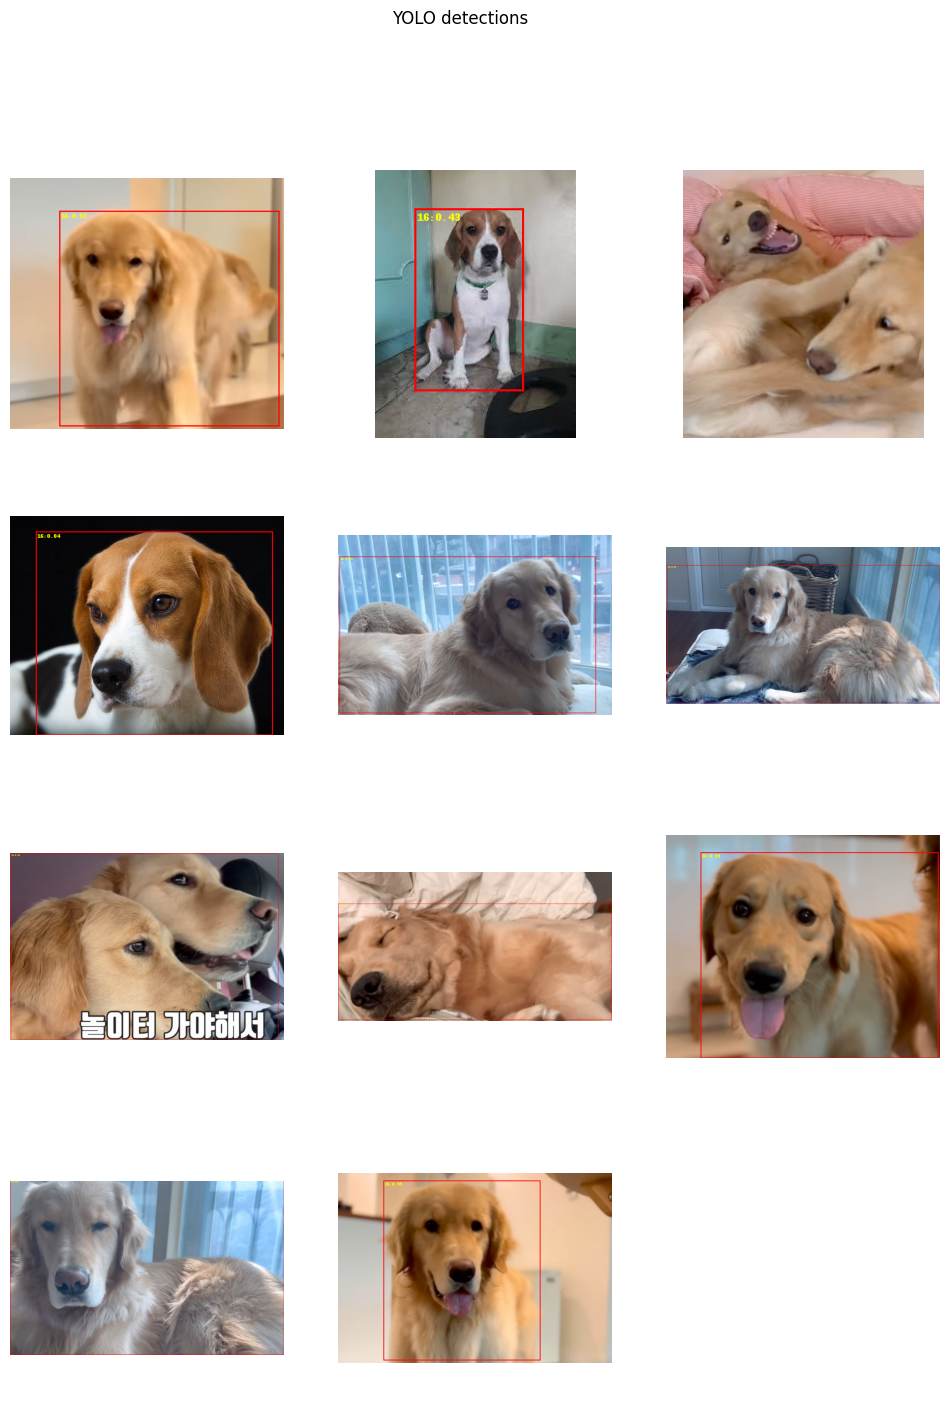

In [10]:
vis = []
for img in images:
    dets = detector.detect(img)
    vis.append(draw_boxes(img, dets))

show_grid(vis, cols=3, title='YOLO detections')
